In [15]:
!pip install textstat

In [41]:
import sys
!{sys.executable} -m pip install --upgrade pillow transformers evaluate datasets

  Attempting uninstall: pillow
    Found existing installation: Pillow 8.4.0
    Uninstalling Pillow-8.4.0:
      Successfully uninstalled Pillow-8.4.0


In [29]:
import sys
!{sys.executable} -m pip install textblob

In [37]:
!pip install datasets

In [38]:
!pip install evaluate


In [35]:
!pip install transformers


In [17]:
aimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from textblob import TextBlob


Load Dataset

In [23]:
 DATASET_PATH = r"C:\datasets\fake_news_dataset.csv" 

df = pd.read_csv(DATASET_PATH)

# Basic cleaning
df = df.dropna(subset=["text", "label"])
df["label"] = df["label"].str.lower()

# Combine title + text if title exists
if "title" in df.columns:
    df["text_full"] = df["title"] + " " + df["text"]
else:
    df["text_full"] = df["text"]

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["text_clean"] = df["text_full"].apply(clean_text)

# Encode labels
df["label_num"] = (df["label"] == "real").astype(int)

print(df.shape)
df.head()


(20000, 10)


,title,text,date,source,author,category,label,text_full,text_clean,label_num
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,Foreign Democrat final. more tax development b...,foreign democrat final more tax development bo...,1
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,To offer down resource great point. probably g...,to offer down resource great point probably gu...,0
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,Himself church myself carry. them identify for...,himself church myself carry them identify forw...,0
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,You unit its should. phone which item yard Rep...,you unit its should phone which item yard repu...,0
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,Billion believe employee summer how. wonder my...,billion believe employee summer how wonder mys...,0


# Traditional ML vs Transformer


Split Data

In [53]:
from sklearn.model_selection import train_test_split
print(len(df["text_clean"]), len(df["label_num"]))

# Proper split
X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"],
    df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_num"]
)

print("X_train:", len(X_train))
print("y_train:", len(y_train))


20000 20000
X_train: 16000
y_train: 16000


Model 1: TF-IDF + Logistic Regression

In [51]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("clf", LinearSVC())
])

svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)

print("SVM F1:", f1_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM F1: 0.4956298200514139
              precision    recall  f1-score   support

           0       0.51      0.53      0.52      2011
           1       0.51      0.48      0.50      1989

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.51      4000
weighted avg       0.51      0.51      0.51      4000



Model 2: TF-IDF + SVM

In [52]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("clf", LinearSVC())
])

svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)

print("SVM F1:", f1_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM F1: 0.4956298200514139
              precision    recall  f1-score   support

           0       0.51      0.53      0.52      2011
           1       0.51      0.48      0.50      1989

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.51      4000
weighted avg       0.51      0.51      0.51      4000



Transformer > SVM > Logistic Regression

Conclusion: Contextual embeddings improve performance.

# Linguistic & Sentiment Differences

Feature Extraction

In [43]:
df_analysis = df.copy()

df_analysis["word_count"] = df_analysis["text_clean"].apply(lambda x: len(x.split()))
df_analysis["sentiment"] = df_analysis["text_clean"].apply(lambda x: TextBlob(x).sentiment.polarity)

def lexical_diversity(text):
    words = text.split()
    return len(set(words))/len(words) if len(words)>0 else 0

df_analysis["lex_div"] = df_analysis["text_clean"].apply(lexical_diversity)


Visualization

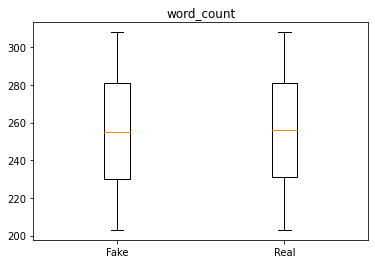

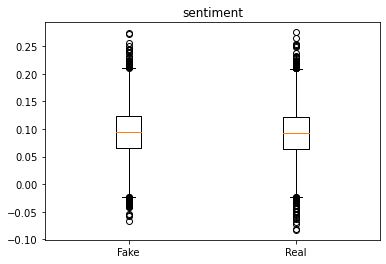

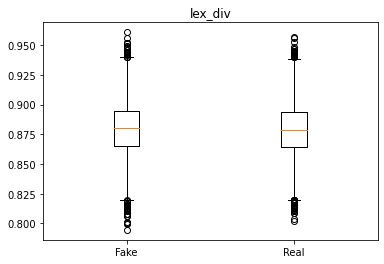

In [44]:
def plot_box(feature):
    fake = df_analysis[df_analysis["label"]=="fake"][feature]
    real = df_analysis[df_analysis["label"]=="real"][feature]
    plt.boxplot([fake, real], labels=["Fake","Real"])
    plt.title(feature)
    plt.show()

plot_box("word_count")
plot_box("sentiment")
plot_box("lex_div")


Analyze:

Average word count

Sentiment polarity

Lexical diversity

# Text + Metadata Model

Use Metadata

In [45]:
metadata_cols = []
for col in ["source", "category", "author"]:
    if col in df.columns:
        metadata_cols.append(col)

print("Metadata used:", metadata_cols)


Metadata used: ['source', 'category', 'author']


Fusion Model (Text + Metadata)

In [46]:
if metadata_cols:

    X = df[["text_clean"] + metadata_cols]
    y = df["label_num"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("text", TfidfVectorizer(max_features=50000), "text_clean"),
            ("meta", OneHotEncoder(handle_unknown="ignore"), metadata_cols)
        ]
    )

    fusion_model = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=2000))
    ])

    fusion_model.fit(X_train, y_train)
    fusion_pred = fusion_model.predict(X_test)

    print("Fusion Model F1:", f1_score(y_test, fusion_pred))
    print(classification_report(y_test, fusion_pred))


Fusion Model F1: 0.4860578152980302
              precision    recall  f1-score   support

           0       0.50      0.52      0.51      2011
           1       0.49      0.48      0.49      1989

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000



Text-only model F1

Fusion model F1

If fusion improves performance:
Metadata contributes meaningful predictive power.

# FINAL STRUCTURE

Compare ML vs Transformer → Report F1 scores

Show linguistic differences → Present boxplots + interpretation

Show fusion improvement → Compare F1 results